#Deep Ritz Method for a Static Plate Problem
Our goal is to apply the *Deep Ritz* method to a 2D static plate problem:
\begin{align}
\nabla.\sigma + p = 0\ \text{on}\ {\rm int}(\Omega),
\end{align}
where $\Omega = [0,L]\times [0,L]$. We assume that the plate is subject to the following boundary condition:
1. **Bottom**: $u_2(x_1,0)=0,\ \sigma_{12}(x_1,0)=0$;
2. **Left**: $u_1(0,x_2)=0,\ \sigma_{12}(0,x_2)=0$;
3. **Top**: $\sigma_{22}(x_1,L)=0,\ \sigma_{12}(x_1,L)=0$;
4. **Right**: $\sigma_{11}(L,x_2)=t_0,\ \sigma_{12}(L,x_2)=0$.

<p align="center">
<img src="https://drive.google.com/uc?id=1XN_D-7JL003f1AH3xgmcPVea873EEZ8m", width="300">

The analytical solution for the displacement field of this problem is
\begin{align}
u = [\tfrac{t_0}{E}x_1,\ -\tfrac{\nu t_0}{E}x_2]^\top
\end{align}
In the deep Ritz method, we will work with the energy formulation of the problem, where the goal is to minimize the potential functional
\begin{align}
\Pi = \Pi_{\rm int} + \Pi_{\rm ext}
\end{align}
which comprises the internal $$\Pi_{\rm int} = \frac{1}{2} \int_{\Omega} \sigma \colon \epsilon\ {\rm d}\Omega$$ and the external $$\Pi_{\rm ext} = - \int_{\Omega} p.u\ {\rm d}\Omega - \int_{\Gamma_N} t.u\ {\rm d}\Gamma$$ components.

This example is taken from the following reference:

L. Herrmann, et al., *Deep Learning in Computational Mechanics: An Introductory Course*. Cham: Springer Nature Switzerland, 2025.


Installing `equinox`:

In [ ]:
!pip install equinox

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 2.3 MB/s eta 0:00:00


Imports:

In [ ]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax
import matplotlib.pyplot as plt
import itertools
import copy

Defining the domain, $\Omega$:

In [ ]:
x1_min, x1_max = 0.0, 1.0
x2_min, x2_max = 0.0, 1.0

##Gaussian Quadrature
Evaluating the potential terms requires numeriacl integration over the domain or boundary. For this porpose, we will use *Gaussian quadrature* in both 1D and 2D.

In [ ]:
GQ_order = 4 # order of the Gaussian quadrature
x_GQ, w_GQ = np.polynomial.legendre.leggauss(GQ_order) # nodes and weight
x_GQ = jnp.asarray(x_GQ)
w_GQ = jnp.asarray(w_GQ)
print(x_GQ)
print(w_GQ)

# transforming the nodes along each dimension: [-1, 1] ---> [x_min, x_max]
x1_GQ = 0.5 * (x1_max - x1_min) * x_GQ + 0.5 * (x1_max + x1_min)
x2_GQ = 0.5 * (x2_max - x2_min) * x_GQ + 0.5 * (x2_max + x2_min)

# Tensor product (2D) of nodes and weights
X_GQ = jnp.asarray(list(itertools.product(x1_GQ, x2_GQ)))
print(X_GQ.shape)
W_list = jnp.asarray(list(itertools.product(w_GQ, w_GQ)))
#print(W_list.shape)
W_GQ = jnp.prod(W_list, axis=1)
#print(W_GQ.shape)

# Jacobian factor (2D)
GQ_jacob = 0.25 * (x1_max - x1_min) * (x2_max - x2_min)

# Nodes at the right boundary x1=x1_max
X_right_GQ = jnp.stack([jnp.ones_like(x2_GQ) * x1_max, x2_GQ], axis=1)

# Jacobian factor (right boundary)
GQ_jacob_boundary = 0.5 * (x2_max - x2_min)

[-0.8611363  -0.33998105  0.33998105  0.8611363 ]
[0.34785485 0.65214515 0.65214515 0.34785485]
(16, 2)


##PINN Ansatz
In the Ritz approximation method, the ansatz should satisfy the Dirichlet boundary conditions. We will achieve this via *strong enforcement* rather than taking them later into optimization constraints. Accordingly, we form the approximation
$$u(x)\approx \hat{u}(x;\theta) = x \odot {\rm NN}(x;\theta)$$

In [ ]:
# Initialization key
key = jax.random.PRNGKey(42)
key, init_key = jax.random.split(key)

Neural network part, $NN(x;\theta)$ defined as an MLP:

In [ ]:
pinn = eqx.nn.MLP(
    in_size=2,
    out_size=2,
    width_size=10,
    depth=4,
    activation=jax.nn.tanh,
    key=init_key,
)

This function returns the *enforced* version of the PINN, $x\odot {\rm NN}(x;\theta)$:

In [ ]:
def Ritz_ansatz(network, x):
  return x * network(x)

In [ ]:
Ritz_ansatz(pinn, jnp.array([0.5,0.5]))

Array([0.16129795, 0.17466748], dtype=float32)

##Strain Tensor

We calculate the *strain tensor* from the enforced version of the PINN: $$\epsilon = \frac{1}{2} \left( \nabla u + \nabla u^\top \right)$$

In [ ]:
def Strain_Tensor(network, x):
  u_grad = jax.jacrev(Ritz_ansatz, argnums=1)(network, x)
  e_tensor = 0.5 * (u_grad + u_grad.T)
  return e_tensor

In [ ]:
Strain_Tensor(pinn, jnp.array([0.5,0.5]))

Array([[0.32516772, 0.02368946],
       [0.02368946, 0.36217213]], dtype=float32)

##Constitutive Relation

The *plane stress* constituitive equation in the Voigt notation is given by
\begin{align}
\begin{bmatrix} \sigma_{11} \\ \sigma_{22} \\ \sigma_{12} \end{bmatrix} = \frac{E}{1-\nu^2}\begin{bmatrix} 1 & \nu & 0 \\
\nu & 1 & 0 \\
0 & 0 & 1 - \nu
\end{bmatrix} \begin{bmatrix} \epsilon_{11} \\ \epsilon_{22} \\ \epsilon_{12} \end{bmatrix}
\end{align} where $E$ is the Young's modulus and $\nu$ is the Poisson ratio.

In [ ]:
E, nu = 1, 0.3
Elasticity_Tensor = jnp.zeros((3,3))
Elasticity_Tensor = Elasticity_Tensor.at[0,0].set(1.0)
Elasticity_Tensor = Elasticity_Tensor.at[0,1].set(nu)
Elasticity_Tensor = Elasticity_Tensor.at[1,1].set(1.0)
Elasticity_Tensor = Elasticity_Tensor.at[1,0].set(nu)
Elasticity_Tensor = Elasticity_Tensor.at[2,2].set(1.0 - nu)
Elasticity_Tensor = Elasticity_Tensor * (E / (1 - nu**2))

print(Elasticity_Tensor)

[[1.0989012  0.32967037 0.        ]
 [0.32967037 1.0989012  0.        ]
 [0.         0.         0.7692308 ]]


##Stress Tensor

The following function calculates the stress tensor, $\sigma$ from the strain tensor, $\epsilon$ based on the above constitutive equation:

In [ ]:
def Stress_Tensor(network, x):
  # strain tensor
  e = Strain_Tensor(network, x)
  # Voigt form of strain tensor
  e_Voigt = jnp.array([e[0,0], e[1,1], e[0,1]])
  # Voigt form of stress tensor
  s_Voigt = Elasticity_Tensor @ e_Voigt
  # Tensor form
  s = jnp.array([[s_Voigt[0], s_Voigt[2]], [s_Voigt[2], s_Voigt[1]]])
  return s

In [ ]:
Stress_Tensor(pinn, jnp.array([0.5,0.5]))

Array([[0.4767246 , 0.01822266],
       [0.01822266, 0.50518954]], dtype=float32)

##Internal Potential: Strain Energy
The internal potential of the plate is given by its strain energy:
$$\Pi_{\rm int} = \frac{1}{2} \int\limits_{0}^{L}\int\limits_{0}^{L} \sigma \colon \epsilon \ {\rm d}x{\rm d}y = \frac{1}{2} \int\limits_{0}^{L}\int\limits_{0}^{L} \sigma_{ij} \epsilon_{ij} \ {\rm d}x{\rm d}y$$
We first obtain the strain energy density as the inner product of the strain and stress tensors. Then, we calculate the strain energy using this density evaluated at the Gaussian quadrature nodes.

In [ ]:
def Strain_Energy_Density(network, x):
  return 0.5 * jnp.sum( Stress_Tensor(network, x) * Strain_Tensor(network, x) )

def Internal_Potential(network):
  dU_vals = jax.vmap(Strain_Energy_Density, in_axes=(None,0))(network, X_GQ)
  return jnp.sum(W_GQ * dU_vals) * GQ_jacob

In [ ]:
Internal_Potential(pinn)

Array(0.16917872, dtype=float32)

##External Potential
Since there are no body forces, we only need to compute the potential associated with the surface traction at the boundaries, which reduces to
\begin{align}
\Pi_{\rm ext} = - \int_{0}^{L}u_1(L,x_2)t_0\ {\rm d}x_2
\end{align}

In [ ]:
t0 = 1.0 # uniform traction at the right edge
def External_Potential(network):
  u_boundary = jax.vmap(Ritz_ansatz, in_axes=(None,0))(network, X_right_GQ)
  U_val = -GQ_jacob_boundary * t0 * jnp.sum( u_boundary[:,0] * w_GQ )
  return U_val

In [ ]:
External_Potential(pinn)

Array(-0.3251728, dtype=float32)

In [ ]:
def Total_Potential(network):
  return Internal_Potential(network) + External_Potential(network)

We set up an optimizer in `optax`:

In [ ]:
l_rate = 1e-03
optimizer = optax.adam(learning_rate=l_rate)
opt_state = optimizer.init(eqx.filter(pinn, eqx.is_array))

We define a function that will cary out the model/optimizer update at each training epoch.

In [ ]:
@eqx.filter_jit
def Make_Step(network, state):
  loss, grads = eqx.filter_value_and_grad(Total_Potential)(network)
  updates, new_state = optimizer.update(grads, state)
  new_network = eqx.apply_updates(network, updates)
  return new_network, new_state, loss

##Training Loop
We implement an early stoppage mechanism. This will reduce the risk of overfitting that can occur in energy-based PINNs.

In [ ]:
N_epochs = 10_000
Potential_History = []
best_loss = float("inf")
delta_impovement = 1e-05
patience = 50
wait = 0

for epoch in range(N_epochs):

  pinn, opt_state, loss = Make_Step(pinn, opt_state)
  loss_value = float(loss)
  Potential_History.append(loss_value)

  if loss_value < best_loss - delta_impovement:
    best_loss = loss_value
    best_pinn = copy.deepcopy(pinn)
    wait = 0
  else:
    wait += 1

  if epoch % 100 == 0:
    print(f"Epoch: {epoch}, Loss: {loss}")

  if wait >= patience:
    print(f"Early stopping at epoch {epoch}; Best loss: {best_loss}")
    break

pinn = best_pinn

Epoch: 0, Loss: -0.15599413216114044
Epoch: 100, Loss: -0.498629093170166
Epoch: 200, Loss: -0.4996914863586426
Epoch: 300, Loss: -0.4998977780342102
Epoch: 400, Loss: -0.49993500113487244
Early stopping at epoch 447; Best loss: -0.49993446469306946


Let's plot the evolution of total potential $\Pi $ during the training epochs:

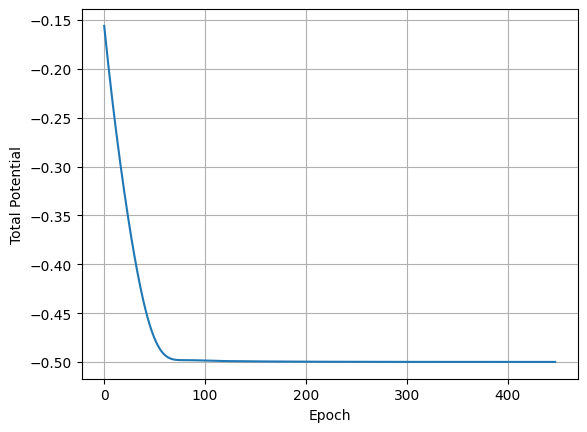

In [ ]:
plt.plot(Potential_History)
# plt.yscale("log")
plt.xlabel(r"Epoch")
plt.ylabel(r"Total Potential")
plt.grid()
plt.show()

###Plotting the learned displacement field:

(10000, 2)


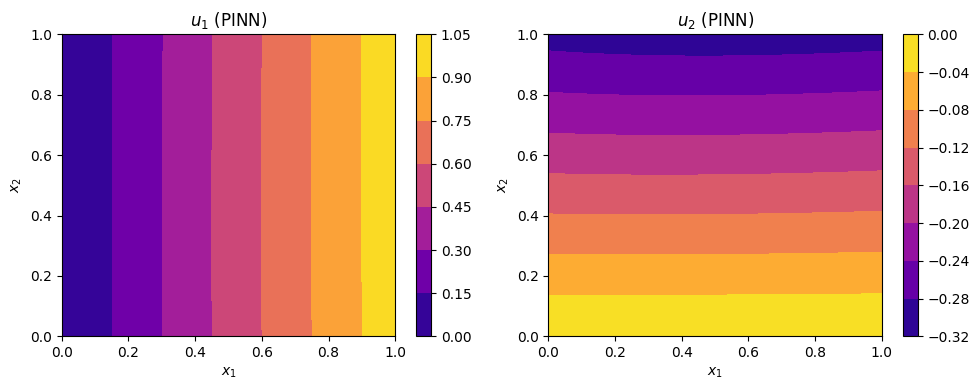

In [ ]:
x1_grid = jnp.linspace(x1_min, x1_max, 100)
x2_grid = jnp.linspace(x2_min, x2_max, 100)
X1_grid, X2_grid = jnp.meshgrid(x1_grid, x2_grid)

X1X2_grid = jnp.stack([X1_grid.ravel(), X2_grid.ravel()], axis=1)
print(X1X2_grid.shape)

U_pinn = jax.vmap(Ritz_ansatz, in_axes=(None,0))(pinn, X1X2_grid)
Ux1_pinn = U_pinn[:,0].reshape(100, 100)
Ux2_pinn = U_pinn[:,1].reshape(100, 100)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.contourf(X1_grid, X2_grid, Ux1_pinn, cmap='plasma')
plt.colorbar()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"$u_1$ (PINN)")

plt.subplot(1,2,2)
plt.contourf(X1_grid, X2_grid, Ux2_pinn, cmap='plasma')
plt.colorbar()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"$u_2$ (PINN)")
plt.tight_layout()
plt.show()

Comparsion against the exact solution:

In [ ]:
def exact_Sol(x):
  return (t0 / E) * jnp.array([x[0], -nu*x[1]])

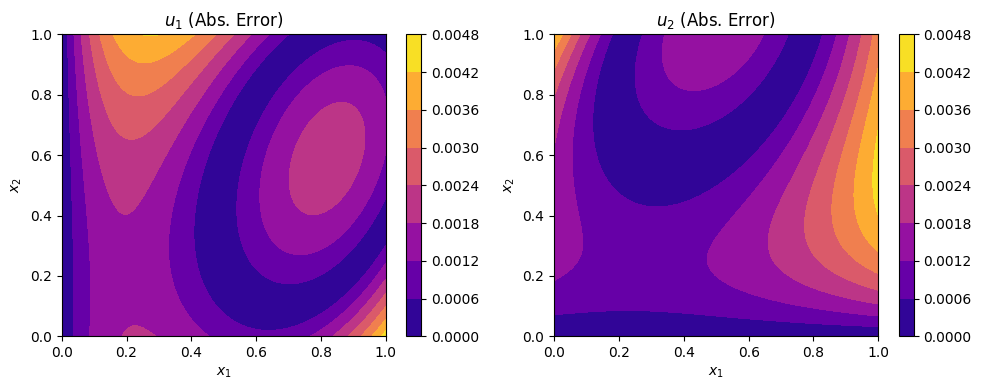

In [ ]:
U_exact = jax.vmap(exact_Sol)(X1X2_grid)
Ux1_exact= U_exact[:,0].reshape(100, 100)
Ux2_exact = U_exact[:,1].reshape(100, 100)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.contourf(X1_grid, X2_grid, jnp.abs(Ux1_exact - Ux1_pinn), cmap='plasma')
plt.colorbar()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"$u_1$ (Abs. Error)")

plt.subplot(1,2,2)
plt.contourf(X1_grid, X2_grid, jnp.abs(Ux2_exact - Ux2_pinn), cmap='plasma')
plt.colorbar()
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title(r"$u_2$ (Abs. Error)")
plt.tight_layout()
plt.show()

###Plotting the strain & stress fields
Exact values:
\begin{align}
&\epsilon_{11} = \frac{t_0}{E},\ \epsilon_{22} = \frac{-\nu t_0}{E},\ \epsilon_{12} = 0\\
&\sigma_{11} = \frac{E}{1-\nu^2}(\epsilon_{11} + \nu \epsilon_{22})=t_0,\ \sigma_{22} = \frac{E}{1-\nu^2}(\nu \epsilon_{11} +  \epsilon_{22})=0,\ \sigma_{12} = \frac{E}{1-\nu^2}(1-\nu)\epsilon_{12}=0
\end{align}
Recall that we work with the normalized parameters $E=1$, $\nu=0.3$, and $t_0=1$.

(10000, 2, 2)


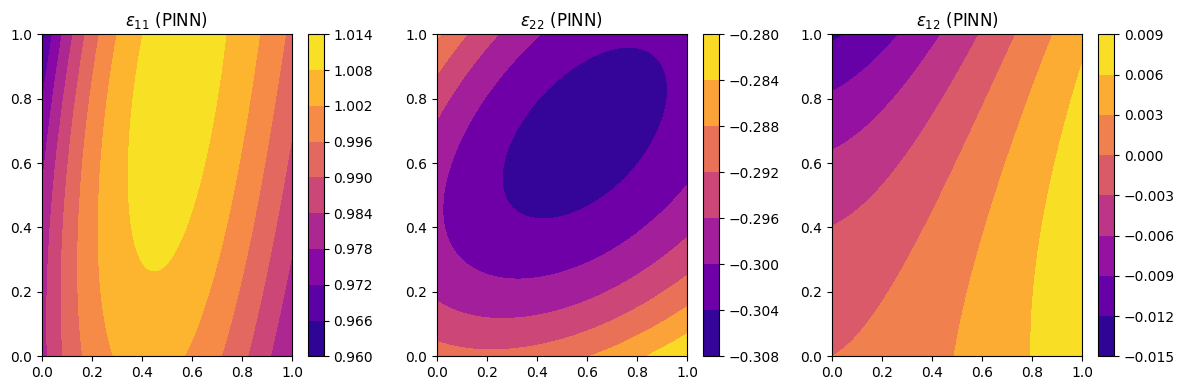

In [ ]:
Strain_pinn = jax.vmap(Strain_Tensor, in_axes=(None,0))(pinn, X1X2_grid)
print(Strain_pinn.shape)

e11_pinn = Strain_pinn[:,0,0].reshape(100, 100)
e12_pinn = Strain_pinn[:,0,1].reshape(100, 100)
e22_pinn = Strain_pinn[:,1,1].reshape(100, 100)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_grid, X2_grid, e11_pinn, cmap='plasma')
plt.title(r"$\epsilon_{11}$ (PINN)")
plt.colorbar()

plt.subplot(1,3,2)
plt.contourf(X1_grid, X2_grid, e22_pinn, cmap='plasma')
plt.title(r"$\epsilon_{22}$ (PINN)")
plt.colorbar()

plt.subplot(1,3,3)
plt.contourf(X1_grid, X2_grid, e12_pinn, cmap='plasma')
plt.title(r"$\epsilon_{12}$ (PINN)")
plt.colorbar()
plt.tight_layout()
plt.show()

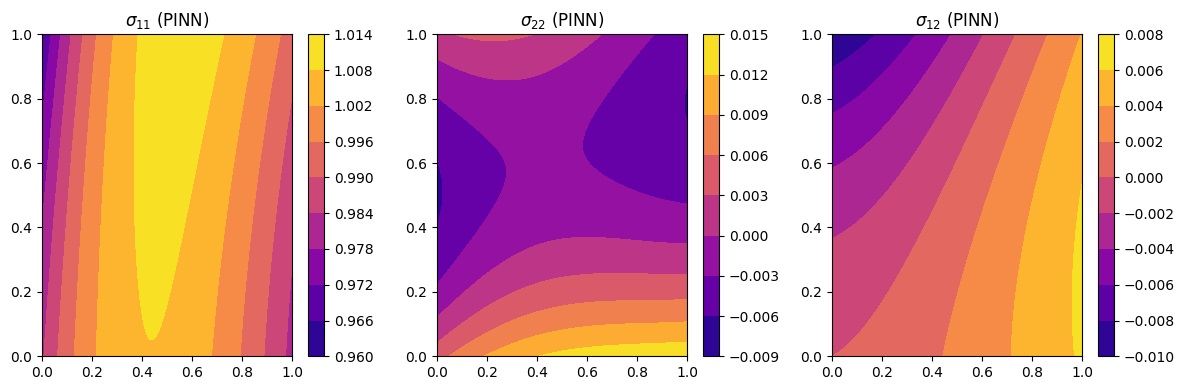

In [ ]:
Stress_pinn = jax.vmap(Stress_Tensor, in_axes=(None,0))(pinn, X1X2_grid)

s11_pinn = Stress_pinn[:,0,0].reshape(100, 100)
s12_pinn = Stress_pinn[:,0,1].reshape(100, 100)
s22_pinn = Stress_pinn[:,1,1].reshape(100, 100)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.contourf(X1_grid, X2_grid, s11_pinn, cmap='plasma')
plt.title(r"$\sigma_{11}$ (PINN)")
plt.colorbar()

plt.subplot(1,3,2)
plt.contourf(X1_grid, X2_grid, s22_pinn, cmap='plasma')
plt.title(r"$\sigma_{22}$ (PINN)")
plt.colorbar()

plt.subplot(1,3,3)
plt.contourf(X1_grid, X2_grid, s12_pinn, cmap='plasma')
plt.title(r"$\sigma_{12}$ (PINN)")
plt.colorbar()
plt.tight_layout()
plt.show()